# ENVS 117 Exercise 1: Setting Up Your Python Toolkit

**Name:** Victoria Romic

**Today's goals**
1. Confirm that Python and Anaconda are working on your computer.
2. Learn how Jupyter notebooks work: cells, Markdown, and execution order.
3. Run the *same* notebook in JupyterLab and in Google Colab and compare.
4. Save your work to GitHub.

**How to run a cell:** click inside it and press `Shift + Enter`.

## Part 1. Where am I running?

Run the cell below. Write down the output. You will run this same cell again in Google Colab later and compare.

In [1]:
import sys
import os
import platform

in_colab = "google.colab" in sys.modules

print("Running in Google Colab:", in_colab)
print("Python version:        ", platform.python_version())
print("Python executable:     ", sys.executable)
print("Operating system:      ", platform.system(), platform.release())

Running in Google Colab: False
Python version:         3.11.16
Python executable:      /opt/anaconda3/envs/envs117/bin/python
Operating system:       Darwin 25.6.0


## Part 2. Which packages do I have?

Packages are add-ons that give Python new abilities. Anaconda and Colab both come with many packages preinstalled, but not always the same ones or the same versions.

In [2]:
import numpy as np
import pandas as pd
import matplotlib

print(f"{'numpy':<12} {np.__version__}")
print(f"{'pandas':<12} {pd.__version__}")
print(f"{'matplotlib':<12} {matplotlib.__version__}")

# geopandas is the main package we will use for vector GIS data.
# It may or may not be installed yet. Either result is fine today.
try:
    import geopandas as gpd
    print(f"{'geopandas':<12} {gpd.__version__}")
except ImportError:
    print("geopandas is NOT installed in this environment (that is OK for today)")

numpy        2.4.6
pandas       3.0.6
matplotlib   3.11.2
geopandas    1.1.4


## Part 3. Where are my files?

Every notebook has a **working directory**: the folder Python looks in when you give it a file name. Most "file not found" errors come from being in a different folder than you think.

In [3]:
print("Current working directory:")
print(os.getcwd())

print("\nFiles and folders here:")
for item in sorted(os.listdir(".")):
    print("  ", item)

Current working directory:
/Users/victoriaromic/Downloads

Files and folders here:
   .DS_Store
   .RData
   .Rhistory
   .ipynb_checkpoints
   .localized
   02themorning-nl-ebola-lbvk-articleLarge.jpg.webp
   069649ae-cf0a-4466-928a-60b2fccd7067_map_500020.pdf
   07700002656_Transcript.pdf
   0_GEOROC
   0_GEOROC.zip
   1-s2.0-S1750583623001809-main.pdf
   1-s2.0-S1750583623001809-mmc1.docx
   10.1038-s41467-022-35582-x-citation.ris
   10.1038-s41467-023-39363-y-citation.ris
   120E Annotated Bibliography (1).pdf
   1780283913.8096871.jpg
   1780283921.02485.jpg
   181353629.pdf
   2024-25 SVPSF Impact Report.pdf
   2024273_EASC08011.pdf
   2025-02-17 19-16.pdf
   2026 Romic LOS.pdf
   2026-Ebola-Affected-Areas-20260522.png
   2027-usa-guidance-for-referees.pdf
   286_SoilAncillaryReport_verB_Aug2020.pdf
   42004_2024_Article_1361.pdf
   606-2.pdf
   606.pdf
   Alpha Sigma Nu Essay.pdf
   Analgesics.csv
   AndamanAndNicobarIslands.pdf
   ArcGISPro_37_199633.exe
   Australia Maps + Gra

## Part 4. Markdown practice

This is a **Markdown cell**. It holds text, not code. Double-click to edit it, then press `Shift + Enter` to render it.

**Your turn:** replace the line below with one sentence about an environmental question you would like to answer with data.

*My question:* I would like to find out which areas in California are most suitable for enhanced rock weathering deployment. 

## Part 5. Execution order matters

Run the next three cells **in order** (A, then B, then C). Then go back and run **cell B again**. What changed, and why?

In [4]:
# Cell A
site_temp_c = 18

In [9]:
# Cell B
print("Doubled temperature:", site_temp_c * 2)

Doubled temperature: 50


In [6]:
# Cell C
site_temp_c = 25

**Now try this:** from the menu, choose **Kernel > Restart Kernel and Run All Cells** (in Colab: **Runtime > Restart session and run all**). Look at the output of cell B again.

*What did you notice?* When you run the three cells in order and then run Cell B again the output changes from 36 to 50. This is because when you run Cell C it overrides what was defined in Cell A. If you restart the Kernel and Run All Cells, the output will remain as 36 because you redefined site_temp_c after running Cell B.  

> Lesson: a notebook remembers what you **ran**, not what you **see** on the screen. Before you submit or share a notebook, always restart and run all cells from top to bottom.

## Part 6. A tiny environmental calculation

The rainfall numbers below are **made-up example values** for a hypothetical station with a Mediterranean climate (wet winters, dry summers), organized by water year (October to September).

Total water-year rainfall: 462 mm (18.2 in)
Wettest month: May


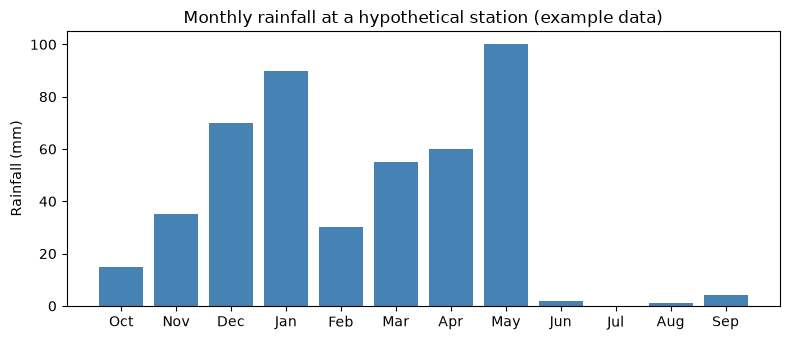

In [11]:
import matplotlib.pyplot as plt

months = ["Oct", "Nov", "Dec", "Jan", "Feb", "Mar",
          "Apr", "May", "Jun", "Jul", "Aug", "Sep"]
rain_mm = [15, 35, 70, 90, 30, 55, 60, 100, 2, 0, 1, 4]   # example values

total_mm = sum(rain_mm)
total_in = total_mm / 25.4
wettest = months[rain_mm.index(max(rain_mm))]

print(f"Total water-year rainfall: {total_mm} mm ({total_in:.1f} in)")
print(f"Wettest month: {wettest}")

plt.figure(figsize=(8, 3.5))
plt.bar(months, rain_mm, color="steelblue")
plt.ylabel("Rainfall (mm)")
plt.title("Monthly rainfall at a hypothetical station (example data)")
plt.tight_layout()
plt.show()

**Your turn:** change one or two values in `rain_mm` and re-run the cell. Does the total update? Does the chart update? 
Yes, both the total and the chart update because we redefined the values before running the code that calculates the total and makes the chart. 

## Part 7. Sneak peek at next week

Next week we cover variables, data types, and control flow. You do not need to understand every line yet. Just run it and guess what each line does.

In [12]:
# Example daily high temperatures (made-up values), in degrees F
site_highs_f = {"Santa Clara": 78, "Fresno": 101, "Lake Tahoe": 64}

for site, temp_f in site_highs_f.items():
    temp_c = (temp_f - 32) * 5 / 9
    if temp_c >= 35:
        label = "extreme heat"
    elif temp_c >= 25:
        label = "warm"
    else:
        label = "mild"
    print(f"{site:<12} {temp_f} F = {temp_c:.1f} C  ->  {label}")

Santa Clara  78 F = 25.6 C  ->  warm
Fresno       101 F = 38.3 C  ->  extreme heat
Lake Tahoe   64 F = 17.8 C  ->  mild


## Part 8. Reflection (answer in this cell)

1. Compare your Part 1 and Part 2 output in JupyterLab vs. Google Colab. What was different?
2. In Part 5, why did cell B print different numbers?
3. Name one situation where you would choose Colab, and one where you would choose JupyterLab.

Answers: 
1. For Part 1, when you run the cell in JupyterLab it outputs "false" to the running in Google Colab because you aren't running in Colab, it's in JupyterLab. Additionally, the versions of python are different as are the operating systems. For Part 2, both JupyterLab and Colab have different versions of the packages numpy, pandas, and matplotlib, but the versions for geopandas is the same.
2. cell B printed different numbers because of the orders in which the cells were ran. If you run a cell defining some variable, in this case site_temp_c, but then you run another cell after that which redefines your variable, python will use the most recent definition to perform operations on it.
3. I think I would use Colab if I wanted to share my work easily because it is a very accesible cloud. I would use JupyterLab if I was working on a more indepth, lengthy project because you can work on it offline and you just have more functionality with JupyterLab. 